# Exploritory Data Analysis

### Olist Company Overview

Olist is the largest department store in Brazilian marketplaces. Olist connects small businesses from all over Brazil to channels without hassle and with a single contract. Those merchants are able to sell their products through the Olist Store and ship them directly to the customers using Olist logistics partners. The Brazilian real (pl. reais; sign: R$; code: BRL) is the official currency of Brazil.

### Business Context & Problem Statement

**Objective**

Analyze the Olist ecommerce dataset to identify the key drivers of revenue, seller performance, logistics effiency, and customer purchasing behavior.

**Business Questions**

* Which sellers generate the most revenue?
* What product categories perform best?
* Does delivery time impact customer satisfaction?
* What geographic regions drive the most sales?

# Dataset Overview

### Import Data

In [383]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import re
import calendar #help get my months names

In [2]:
pd.set_option('display.max_columns', None) #See all of my columns #if I need to revert back: pd.reset_option('display.max_columns')

In [1372]:
df = pd.read_csv('olist_dataset_clean.csv')

In [1373]:
df_1 = df.copy()

### Statistical Overview

In [1374]:
df_1.describe().style.format('{:,.2f}') #A statistical overview of the dataset

,seller_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,order_year,order_month,order_day,order_hour,total_order_value
count,"115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00","115,609.00"
mean,"24,515.71",1.19,120.62,20.06,1.09,2.95,172.39,"35,061.54",48.77,785.81,2.21,"2,113.89",30.31,16.64,23.11,4.03,"2,017.54",6.03,15.56,14.76,140.68
std,"27,636.64",0.69,182.65,15.84,0.73,2.78,265.87,"29,841.67",10.03,652.42,1.72,"3,781.74",16.21,13.47,11.76,1.39,0.51,3.22,8.66,5.32,189.77
min,"1,001.00",1.00,0.85,0.00,1.00,0.00,0.00,"1,003.00",5.00,4.00,1.00,0.00,0.00,0.00,0.00,1.00,"2,016.00",1.00,1.00,0.00,6.08
25%,"6,429.00",1.00,39.90,13.08,1.00,1.00,60.87,"11,310.00",42.00,346.00,1.00,300.00,18.00,8.00,15.00,4.00,"2,017.00",3.00,8.00,11.00,55.37
50%,"13,660.00",1.00,74.90,16.32,1.00,2.00,108.05,"24,241.00",52.00,600.00,1.00,700.00,25.00,13.00,20.00,5.00,"2,018.00",6.00,16.00,15.00,92.01
75%,"28,605.00",1.00,134.90,21.21,1.00,4.00,189.48,"58,745.00",57.00,983.00,3.00,"1,800.00",38.00,20.00,30.00,5.00,"2,018.00",8.00,23.00,19.00,157.79
max,"99,730.00",21.00,"6,735.00",409.68,29.00,24.00,"13,664.08","99,980.00",76.00,"3,992.00",20.00,"40,425.00",105.00,105.00,118.00,5.00,"2,018.00",12.00,31.00,23.00,"6,929.31"


### Columns and Their Datatype

In [1375]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115609 entries, 0 to 115608
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   seller_id                      115609 non-null  object 
 1   seller_zip_code_prefix         115609 non-null  int64  
 2   seller_city                    115609 non-null  object 
 3   seller_state                   115609 non-null  object 
 4   order_id                       115609 non-null  object 
 5   order_item_id                  115609 non-null  int64  
 6   product_id                     115609 non-null  object 
 7   shipping_limit_date            115609 non-null  object 
 8   price                          115609 non-null  float64
 9   freight_value                  115609 non-null  float64
 10  payment_sequential             115609 non-null  int64  
 11  payment_type                   115609 non-null  object 
 12  payment_installments          

### Five Row Overview

In [1376]:
df_1.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_creation_date,review_answer_timestamp,order_year,order_month,order_day,order_hour,day_of_week,year_month,total_order_value,customer_state_name,seller_state_name,customer_region,seller_region
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,4a90af3e85dd563884e2afeab1091394,1,ffb64e34a37740dafb6c88f1abd1fa61,2017-08-25 20:50:19,106.20,9.56,1,credit_card,2,115.76,9d6837f9700a3441e7183bff3bc4eef0,delivered,2017-08-21 20:35:44,2017-08-21 20:50:19,2017-08-29 20:33:29,2017-08-30 16:07:13,2017-09-01 00:00:00,f421a2a66b69dbfe6db0c87845281a90,4661,sao paulo,SP,26.0,417.0,3.0,700.0,43.0,15.0,35.0,sports_leisure,88980a9c50a6909fa1fe35ddab8fa1e2,5,2017-08-31 00:00:00,2017-08-31 21:37:39,2017,8,21,20,Monday,2017-08,115.76,São Paulo,São Paulo,Southeast,Southeast
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,6d953888a914b67350d5bc4d48f2acab,1,f4621f8ad6f54a2e3c408884068be46d,2017-05-11 16:25:11,101.70,15.92,1,credit_card,2,117.62,a973c4e3ad82777add3fa188f91dacea,delivered,2017-05-05 16:12:29,2017-05-05 16:25:11,2017-05-12 05:43:55,2017-06-02 16:57:44,2017-05-30 00:00:00,b4527423469300ee354458e1b5f961be,32223,contagem,MG,27.0,485.0,2.0,600.0,35.0,15.0,28.0,sports_leisure,b9b791819c5c1a5c6a4ffc7881f97fb5,1,2017-06-01 00:00:00,2017-06-01 12:57:10,2017,5,5,16,Friday,2017-05,117.62,Minas Gerais,São Paulo,Southeast,Southeast
2,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,bc8a5de6abf5b14f98a6135a7fb46731,2,325a06bcce0da45b7f4ecf2797dd40e4,2017-09-05 12:50:19,10.80,2.42,1,credit_card,4,158.80,1554ffe702931a062b4383b109accf63,delivered,2017-08-30 11:47:52,2017-08-30 12:50:19,2017-08-30 19:22:18,2017-09-01 16:51:26,2017-09-20 00:00:00,af0f26435fade1ca984d9affda307199,9310,maua,SP,44.0,1089.0,1.0,300.0,16.0,5.0,15.0,sports_leisure,cc77a6d63753c1d7b88b7c64630b97b9,3,2017-09-02 00:00:00,2017-09-03 17:31:14,2017,8,30,11,Wednesday,2017-08,13.22,São Paulo,São Paulo,Southeast,Southeast
3,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,035201c3c82a97f8a25dd6bd5244b2d5,1,1c36a5285f7f3b1ed2637d7c528ce5ff,2017-11-22 04:30:29,89.99,45.09,1,bank_ticket,1,135.08,9facbfd2dd51a45404d58154b12ed2dd,delivered,2017-11-10 16:54:13,2017-11-14 04:31:07,2017-11-14 20:06:59,2017-11-21 23:26:35,2017-12-04 00:00:00,be1401bbfd64455c798bb4683e915c61,22050,rio de janeiro,RJ,21.0,769.0,4.0,1600.0,55.0,37.0,30.0,luggage_accessories,27a894ac7d70600fd49d2ac3b910e65d,5,2017-11-22 00:00:00,2017-11-23 02:14:56,2017,11,10,16,Friday,2017-11,135.08,Rio de Janeiro,São Paulo,Southeast,Southeast
4,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,0504447548229e075dea8441b37b1e2a,1,8852eb03b04ec3268a66e9b696e25f6f,2017-10-06 02:14:42,199.90,21.89,1,bank_ticket,1,221.79,4e2c1f15de98416a90c2ee06b55ccc9b,delivered,2017-09-28 19:31:57,2017-09-30 02:14:42,2017-10-02 19:33:19,2017-10-06 17:03:59,2017-11-03 00:00:00,9a70db677c8e4e9e25e36729362fe756,97700,santiago,RS,30.0,832.0,5.0,2000.0,25.0,55.0,40.0,stationery,265e6d99461ed7db35a7f48a00df7e6c,5,2017-10-07 00:00:00,2017-10-09 10:41:34,2017,9,28,19,Thursday,2017-09,221.79,Rio Grande do Sul,São Paulo,South,Southeast


### Null Value Count Overview

In [1377]:
df_1.isnull().sum()

seller_id                           0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
order_id                            0
order_item_id                       0
product_id                          0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1195
order_delivered_customer_date    2400
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_name_lenght                 0
product_desc

### Business Data Summary

In [400]:
total_orders = df_1['order_id'].nunique()
seller = df_1['seller_id'].nunique()
products = df_1['product_category_name_english'].nunique()
customers = df_1['customer_unique_id'].nunique()

date_format = pd.to_datetime(df_1['order_purchase_timestamp'])
date_range_min_start_date = date_format.min().strftime('%b %Y')
date_range_max_end_date = date_format.max().strftime('%b %Y')


#A Triple_quoted_string - cleaner string formatting
print(f"""
Dataset Summary
---------------
Total Orders: {total_orders:,}
Total Customers: {customers}
Total Sellers: {seller:,}
Total Products: {products:,}
Date Range: {date_range_min_start_date} - {date_range_max_end_date}
""")


Dataset Summary
---------------
Total Orders: 96,516
Total Customers: 93396
Total Sellers: 3,028
Total Products: 71
Date Range: Sep 2016 - Sep 2018



# Univariate Analysis

### Customer State Living In (Marketplace)

* Where are most of our customers located?

In [1378]:
customer_stat = df_1.groupby('customer_state_name')['customer_unique_id'].nunique().sort_values(ascending=False)

top = customer_stat.head().reset_index().copy()
top['customer_unique_id'] = top['customer_unique_id'].map('{:,.0f}'.format)
top = top.rename(columns={'customer_state_name':'State','customer_unique_id': 'Customer ID'})
print("Top 5 States Olist Customers\n")
print(f"{top.to_string(index=False)}")


Top 5 States Olist Customers

            State Customer ID
        São Paulo      39,192
   Rio de Janeiro      11,974
     Minas Gerais      10,948
Rio Grande do Sul       5,151
           Paraná       4,748


**Insight:**

Majority of our customers are located in Sao Paulo (SP), indicating strong demand in this region.

### Highest Sold Product (Sales)

* What is the highest sold product?

In [434]:
products = df_1.loc[df_1['order_status'] == 'delivered'].groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).reset_index()

highest_sold = products['product_category_name_english'].iloc[0]
revenue = products['payment_value'].iloc[0]
total_revenue = products['payment_value'].sum()

percentage = (revenue / total_revenue) * 100

print(f"""
Highest Sold Product Category: {highest_sold}
Revenue Generated: R${revenue:,.2f}
Share of Total Revenue: {percentage:.2f}%
""")


Highest Sold Product Category: bed_bath_table
Revenue Generated: R$1,707,029.45
Share of Total Revenue: 8.79%



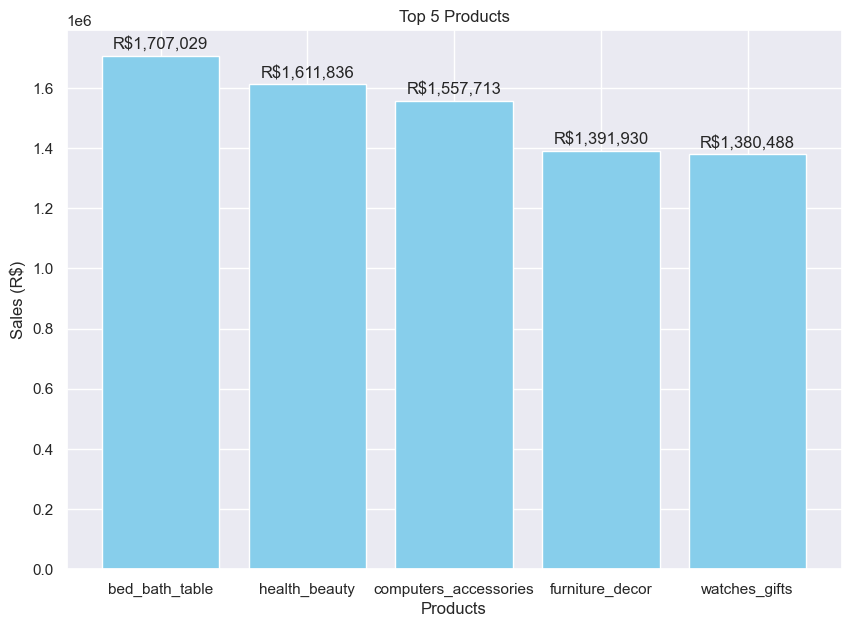

In [1249]:
top_5 = products.head()

plt.figure(figsize=(10, 7))
bars = plt.bar(top_5['product_category_name_english'], top_5['payment_value'], color='skyblue') 
plt.bar_label(bars, padding=3, fmt='R${:,.0f}')
plt.title('Top 5 Products') 
plt.xlabel('Products')
plt.ylabel('Sales (R$)')
plt.show()

**Insight:**

Bed Bath Table is the highest revenue category, contributing to 8.79% of total sales.

### Lowest Sold Product (Sales)

* What is the lowest sold product?

In [447]:
lowest_sold = products['product_category_name_english'].iloc[-1]
lowest_revenue = products['payment_value'].iloc[-1]

total_revenue = products['payment_value'].sum()

percentage = (lowest_revenue / total_revenue) * 100

print(f"""
Lowest Sold Product Category: {lowest_sold}
Revenue Generated: R${lowest_revenue:,.2f}
Share of Total Revenue: {percentage:.3f}%
""")


Lowest Sold Product Category: security_and_services
Revenue Generated: R$324.51
Share of Total Revenue: 0.002%



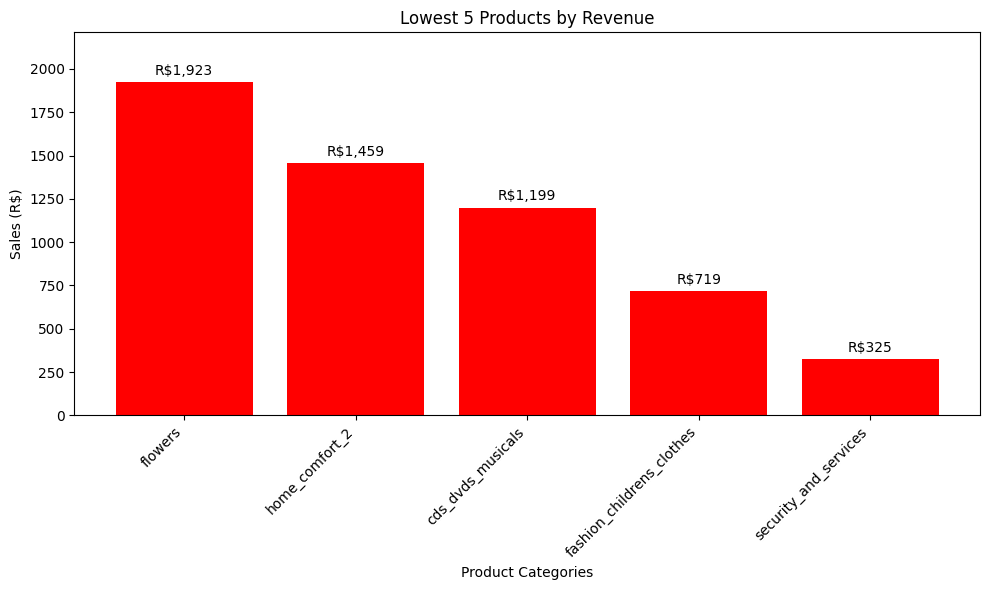

In [532]:
lowest_5 = products.tail()

plt.figure(figsize=(10, 6))

bars = plt.bar(lowest_5['product_category_name_english'], lowest_5['payment_value'], color='red') 

plt.bar_label(bars, padding=3, fmt='R${:,.0f}')

plt.title('Lowest 5 Products by Revenue') 
plt.xlabel('Product Categories')
plt.ylabel('Sales (R$)')
plt.xticks(rotation=45, ha='right')

plt.ylim(0, lowest_5['payment_value'].max() * 1.15) #Expand the bar chart y-axis slightly so labels don't hit the edge

plt.tight_layout()
plt.show()

**Insight:**

Security And Services is the lowest revenue category, contributing to 0.002% of total sales.

### Products Per Category (Customer Behaviour)

* How many units were sold per Category?

In [1245]:
#Highest Units Sold per Category, good for sales dept.
units_sold = df_1['product_category_name_english'].value_counts()

top_10_sum = units_sold.head(10).sum()
top_10 = units_sold.head(10).reset_index()

total_units_sold = units_sold.sum()

percentage = (top_10_sum/total_units_sold) * 100
top_10 = top_10.rename(columns={'product_category_name_english':'Product Category', 'count':'Volume'}) 

print(f"Units Sold Per Category (Top 10):\n\n{top_10.to_string(index=False)}\n")
print(f"The Top 10 Products make up {percentage:,.2f}% of our total products sold.")


Units Sold Per Category (Top 10):

     Product Category  Volume
       bed_bath_table   11847
        health_beauty    9944
       sports_leisure    8942
      furniture_decor    8743
computers_accessories    8105
           housewares    7331
        watches_gifts    6161
            telephony    4692
         garden_tools    4558
                 auto    4356

The Top 10 Products make up 64.60% of our total products sold.


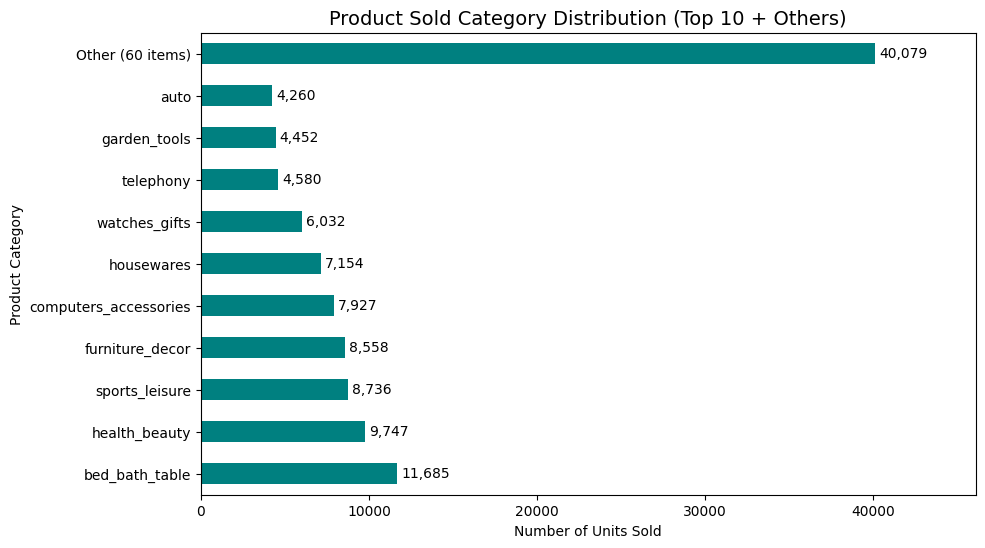

In [527]:
others_count = others_index_reset.iloc[10:].sum()

top = units_sold.head(10)
other = pd.Series({'Other (60 items)': others_count}) #allowing other_count to be updated and not hard coded
final_data = pd.concat([top,other])

ax = final_data.plot(kind='barh', figsize=(10, 6), color='teal')

ax.bar_label(ax.containers[0], padding=3, fmt='{:,.0f}')

plt.title('Product Sold Category Distribution (Top 10 + Others)', fontsize=14)
plt.xlabel('Number of Units Sold')
plt.ylabel('Product Category')

plt.xlim(0, final_data.max() * 1.15) #Expand the x-axis slightly so labels don't hit the edge
plt.show()

**Insight:**

Bed Bath Table products has the highest number of items sold, something popular for Olist customers.

### Average Unit Price (Product)

* What is the average priced unit?

In [593]:
avg_price = df_1['price'].mean()

print(f"Average Priced Unit: R${avg_price:.2f}")

Average Priced Unit: R$120.62


**Insight:**

The average priced unit indicates majority of Olist products are smaller items and priced at a lower pricing tag. Meaning Sellers sell prefer selling smaller priced items on Olist. 

### Average Price Per Category (Product)

* What is the average priced product per category?

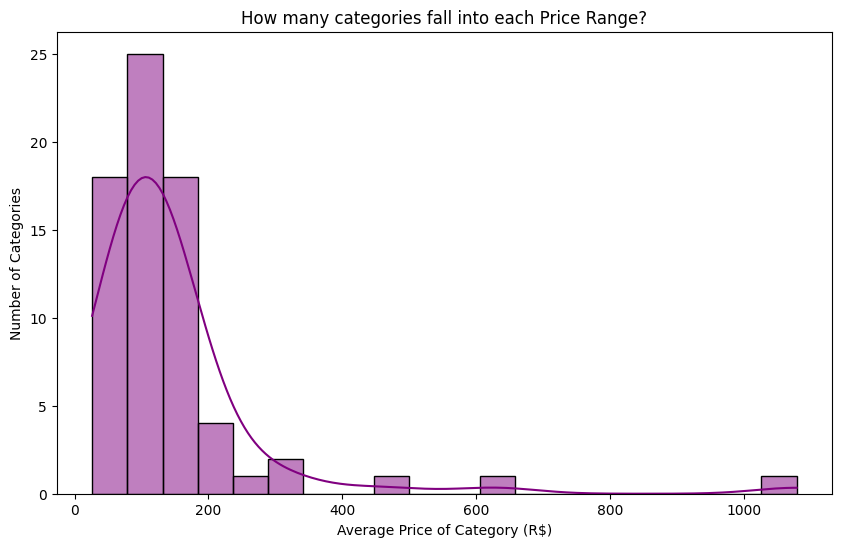

In [595]:
order_stat = df_1
average_unit_price = order_stat.groupby('product_category_name_english')['price'].agg('mean').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.histplot(average_unit_price, kde=True, color='purple', bins=20)
plt.title("How many categories fall into each Price Range?") 
plt.xlabel("Average Price of Category (R$)")
plt.ylabel("Number of Categories")
plt.show()

**Insight:**

Under R$200 are many of Olist items, a loss of 5% of a product over one-thousand of Brazilian real will impact Olist bottom line. 

### Freight Cost (Logistics)

* What are the cost Freight deliveries?

Text(0.5, 1.0, 'Distribution of Freight Costs')

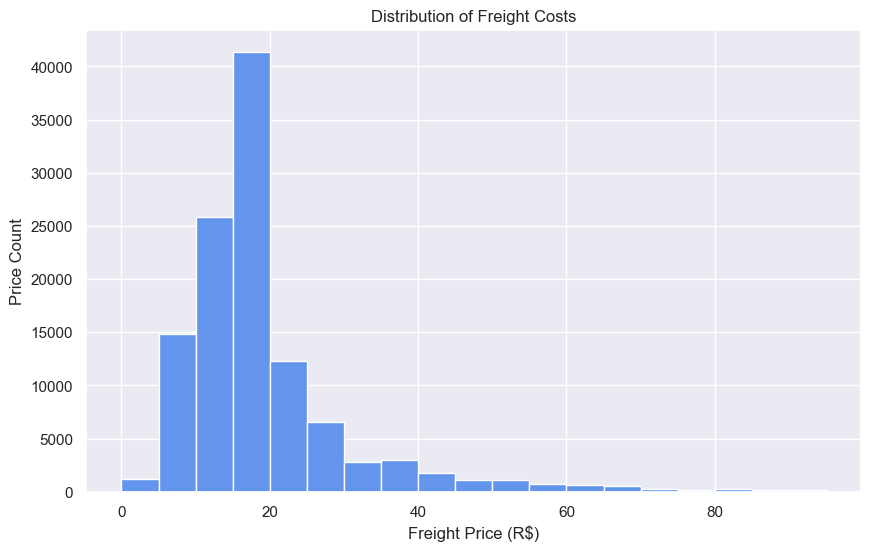

In [606]:
freight_cost = df_1['freight_value']

plt.figure(figsize=(10, 6))
plt.hist(freight_cost, bins=np.arange(0,100, 5), color = 'cornflowerblue')
plt.xlabel("Freight Price (R$)") 
plt.ylabel("Price Count")
plt.title("Distribution of Freight Costs")

**Insight:**

More number of items has a Freight cost close to R$20.

**Section Transition:**

After examining individual variables in the Univariate Analysis, the next step is to explore how different variables interact with one another. Bivariate analysis helps identify relationships between customer behavior, geography, logistics, and revenue.


# Bivariate Analysis

### Freight Cost to Weight (Logistics)

Do heavier products have a higher freight cost?

#### Hypothesis

Heavier products cost more to ship.

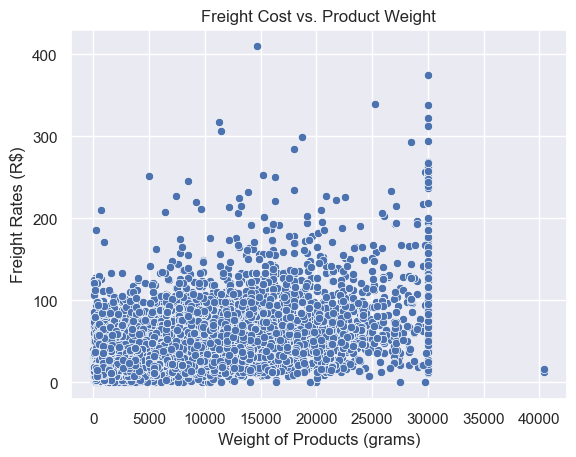

In [609]:
sns.scatterplot(x='product_weight_g', y='freight_value', data=df_1) 
plt.title('Freight Cost vs. Product Weight')
plt.xlabel('Weight of Products (grams)')
plt.ylabel('Freight Rates (R$)')
plt.show()

**Insight:**

Heavier products does not correlate to the rate/cost of a delivery. The cost of a Freight may include more dimensions of a product package, more than only considering weight.

### Region vs Revenue (Sales)

Which regions generate the most revenue?

#### Hypothesis

Regions with more customers generate higher revenue.

In [1379]:
#Statistical code
customer_state_revenue = (df_1[df_1['order_status']== 'delivered']
                          .groupby('customer_state_name')['payment_value']
                          .sum()
                          .sort_values(ascending=False)
                         )
top_customer_5 = customer_state_revenue.head().reset_index()

top_5_revenue = top_customer_5.copy()
top_5_revenue_and_customer_count = top_5_revenue.merge(customer_stat, on='customer_state_name')
top_5_revenue_and_customer_count['payment_value'] = top_5_revenue_and_customer_count['payment_value'].map('{:,.2f}'.format)


top_5_revenue_and_customer_count = top_5_revenue_and_customer_count.rename(columns={'customer_state_name': 'State', 'payment_value':'Total Revenue (R$)', 'customer_unique_id':'Unique Customer ID'})

print(f"Top Five States Generating Highest Revenue\n\n{top_5_revenue_and_customer_count.to_string(index=False)}")

Top Five States Generating Highest Revenue

            State Total Revenue (R$)  Unique Customer ID
        São Paulo       7,321,451.70               39192
   Rio de Janeiro       2,632,981.89               11974
     Minas Gerais       2,245,619.37               10948
Rio Grande do Sul       1,095,891.84                5151
           Paraná       1,022,798.67                4748


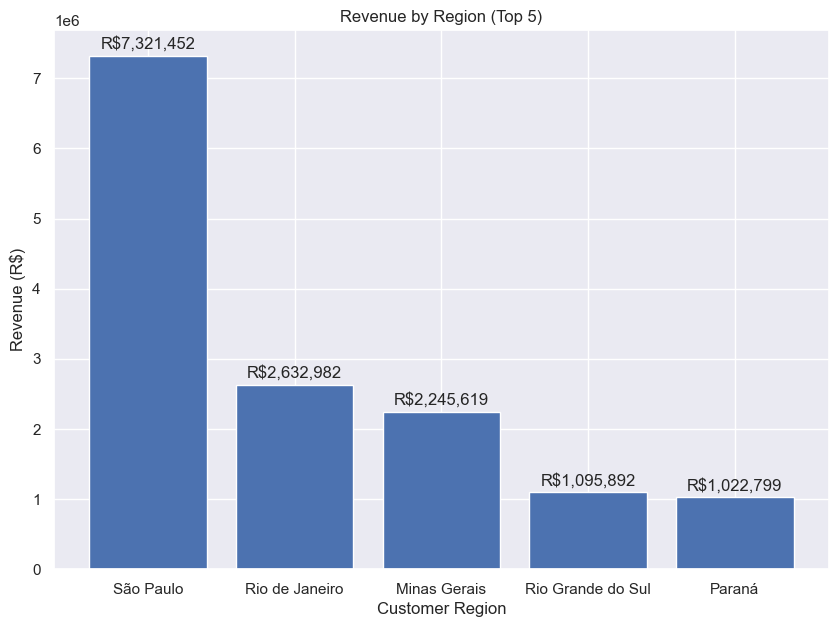

In [1380]:
rev_chart = customer_state_revenue.head().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
bars = plt.bar(rev_chart['customer_state_name'], rev_chart['payment_value'])
plt.bar_label(bars, padding=3, fmt='R${:,.0f}')
plt.title('Revenue by Region (Top 5)')
plt.xlabel('Customer Region')
plt.ylabel('Revenue (R$)')
plt.show()

**Insight:**

Higher population of customers do correlate to generating more revenue. 

### Region vs Expensive Items (Product)

Do customers in certain regions purchase higher-priced products?

#### Hypothesis

Wealthier regions purchase more expensive products.

In [1381]:
orders_delivered = df_1[df_1['order_status']== 'delivered']
region_price_state = (orders_delivered.groupby('customer_state_name')['total_order_value']
                      .agg(['mean', 'max', 'count'])
                      .sort_values(by='mean', ascending=False).reset_index()
                     )

region_price_state['mean'] = region_price_state['mean'].map('{:,.2f}'.format).astype(float)
region_price_state = region_price_state.rename(columns={'customer_state_name': 'State', 'mean':'Average', 'max':'Max', 'count':'Number of Purchases'})

print(f"     States by Higher-Priced Purchases (Top 10)")
print()
print(region_price_state.head(10).to_string(index=False))


     States by Higher-Priced Purchases (Top 10)

              State  Average     Max  Number of Purchases
            Paraíba   234.45 4681.78                  605
               Acre   224.35 1251.70                   92
            Alagoas   217.97 1942.00                  438
           Rondônia   208.85 2452.12                  274
          Tocantins   205.90 2784.16                  329
              Piauí   202.43 1816.11                  541
Rio Grande do Norte   202.39 1821.82                  553
              Amapá   199.10 1482.42                   82
            Roraima   198.58  994.77                   44
               Pará   193.68 2252.66                 1056


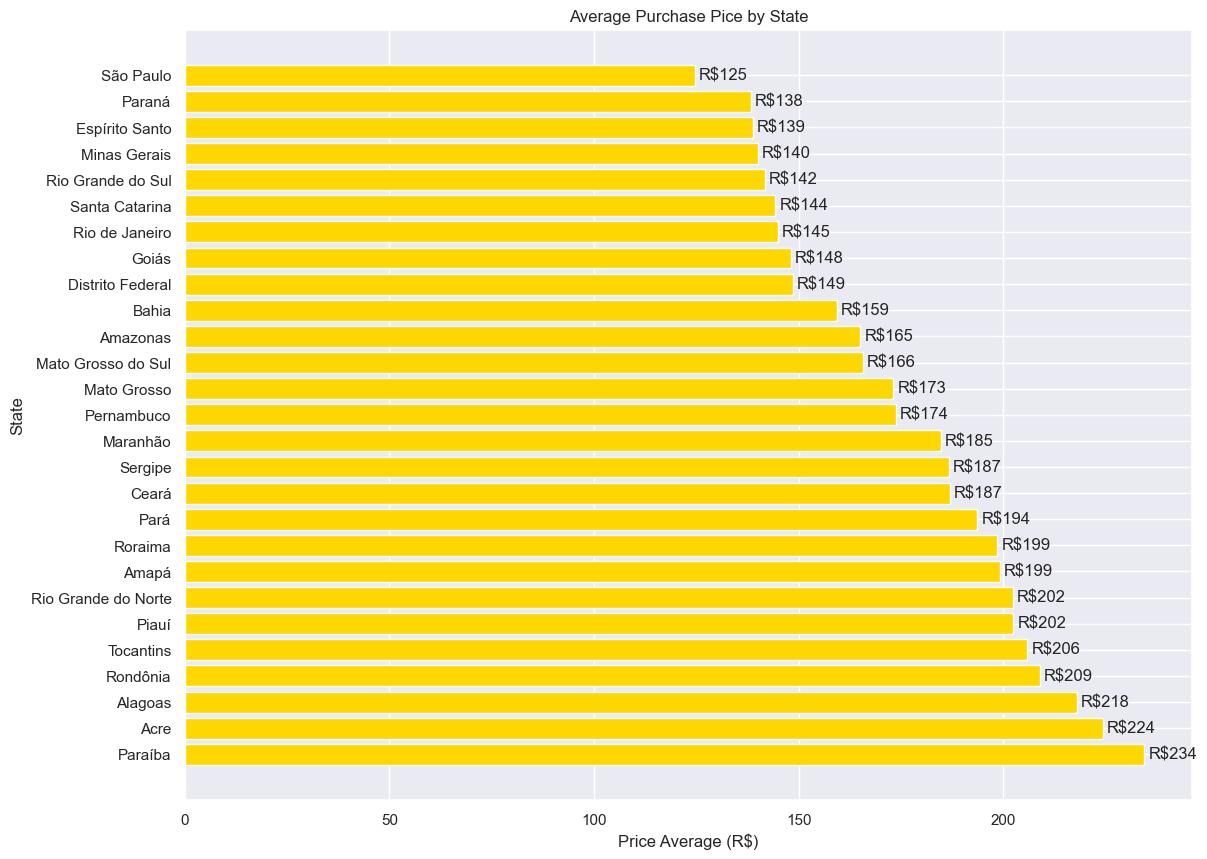

In [1382]:
plt.figure(figsize=(13, 10))
bars = plt.barh(region_price_state['State'], region_price_state['Average'], color='gold') 
plt.bar_label(bars, padding=3, fmt='R${:,.0f}')
plt.title('Average Purchase Pice by State') 
plt.xlabel('Price Average (R$)') 
plt.ylabel('State')
plt.show()

**Insight:**

Paraíba(PB) has the highest priced products on average. 

### Delivery Time vs Region (Logistics)

Do certain regions experience longer delivery times?

#### Hypothesis

Regions farther from sellers have longer delivery times.

In [1383]:
delivered_state = df_1[df_1['order_status']== 'delivered']
delivery = delivered_state.copy()
delivery['order_delivered_customer_date'] = pd.to_datetime(delivery['order_delivered_customer_date'])
delivery['order_delivered_carrier_date'] = pd.to_datetime(delivery['order_delivered_carrier_date'])
delivery['date_count'] = (delivery['order_delivered_customer_date'] - delivery['order_delivered_carrier_date']).dt.days

average_delivery = delivery.groupby(['customer_state_name'])['date_count'].mean().sort_values(ascending=False).reset_index()

average_delivery['date_count'] = average_delivery['date_count'].map('{:,.0f} days'.format)
average_delivery = average_delivery.rename(columns={'customer_state_name':'State', 'date_count':'Number of Days'})

print(f"State by Delivery time\n\n {average_delivery.to_string(index=False)}")

State by Delivery time

               State Number of Days
            Roraima        24 days
              Amapá        24 days
           Amazonas        23 days
            Alagoas        20 days
               Pará        20 days
            Sergipe        17 days
           Maranhão        17 days
              Ceará        17 days
               Acre        17 days
           Rondônia        16 days
            Paraíba        16 days
              Piauí        16 days
Rio Grande do Norte        15 days
              Bahia        15 days
         Pernambuco        14 days
        Mato Grosso        14 days
          Tocantins        13 days
 Mato Grosso do Sul        12 days
              Goiás        12 days
     Espírito Santo        12 days
  Rio Grande do Sul        11 days
     Rio de Janeiro        11 days
     Santa Catarina        11 days
   Distrito Federal         9 days
       Minas Gerais         8 days
             Paraná         8 days
          São Paulo         5 

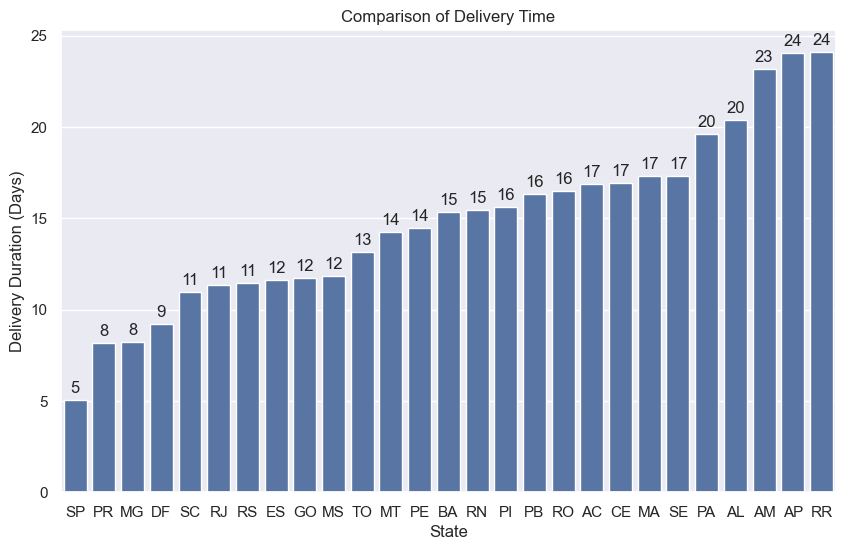

In [1269]:
average_delivery_int = delivery.groupby(['customer_state'])['date_count'].mean().sort_values(ascending=True).reset_index()

# Stacked bar plot to compare total bill amounts by day and time
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='customer_state', y='date_count', data=average_delivery_int) 
ax.bar_label(ax.containers[0], padding=3, fmt='%.0f')

plt.title('Comparison of Delivery Time') 
plt.xlabel('State')
plt.ylabel('Delivery Duration (Days)')
plt.show()

**Insight:**

Shorter delivery time shows Olist Warehouses could be placed closer to a region like Sāo Paulo (SP) having a 5-days shipping average. A warehouse being placed closer to another city (with high returns), can increase revenue.  

### Payment type vs Revenue (Finance)

Which payment method generates the most revenue?

#### Hypothesis

Credit card payments generate the highest revenue.

In [1364]:
transaction_method = (df_1[df_1['order_status']== 'delivered']
                      .groupby('payment_type')['payment_value']
                      .sum()
                      .reset_index().sort_values(by='payment_value',ascending=False)
                     )
payment_value = transaction_method.copy()
payment_value['payment_value'] = payment_value['payment_value'].map('{:,.2f}'.format)
payment_value = payment_value.rename(columns={'payment_type':'Payment Method', 'payment_value':'Total Revenue (R$)'})


print(f"Revenue by Payment Method\n")
print(f"{payment_value.to_string(index=False)}")


Revenue by Payment Method

Payment Method Total Revenue (R$)
   credit_card      14,922,284.79
   bank_ticket       3,871,700.64
       voucher         387,076.56
    debit_card         242,755.14


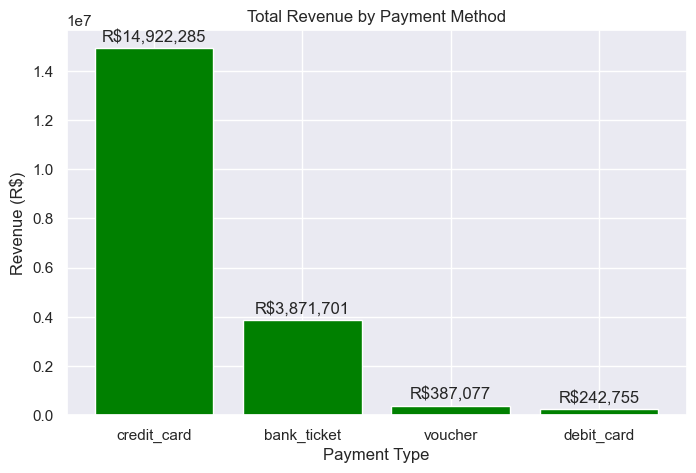

In [1270]:
# Creating figures and axes explicitly
fig, ax = plt.subplots(figsize=(8, 5))
# Creating a bar chart
bars = ax.bar(transaction_method['payment_type'], transaction_method['payment_value'], color='green') 
plt.bar_label(bars, padding=3, fmt='R${:,.0f}')

ax.set_title('Total Revenue by Payment Method') 
ax.set_xlabel('Payment Type') 
ax.set_ylabel('Revenue (R$)')
plt.show()

**Insight:**

Credit card is the customers preferred payment method. 

**Section Transition:**

After examining individual variables in the Bivariate Analysis, the next step is to explore how different variables interact with one another. Time-Series Analysis helps track and measure timesspand between Revenue, Orders,  Delivery.


# Time-Series Analysis

### Revenue per Month (Sales)

Which month generates the most revenue?

#### Hypothesis

Revenue is higher during the 1st & 2nd Quarter (Financial Year).

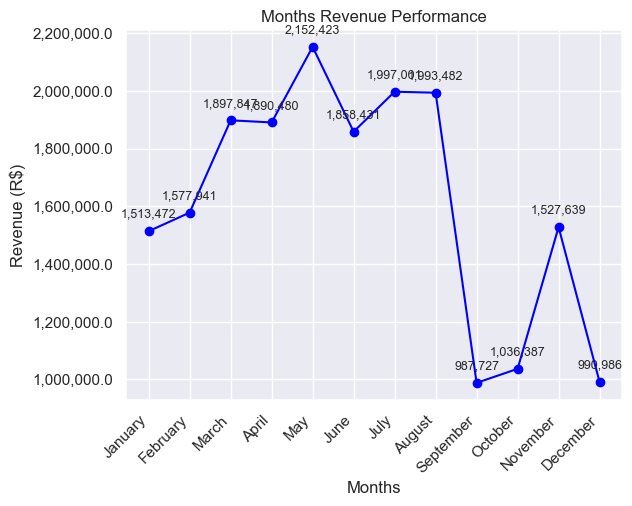

In [1336]:
rev_per_mon = (df_1[['order_month', 'payment_value']]
               .loc[df_1['order_status'] == 'delivered'].groupby('order_month')['payment_value'].sum().reset_index()
)
sales = rev_per_mon.sort_values('order_month')
months_names = [calendar.month_name[i] for i in sales['order_month']]

plt.figsize=(10, 6)
plt.plot(months_names, sales['payment_value'], marker='o', linestyle='-', color='blue')
for i, txt in enumerate(sales['payment_value']):
    plt.annotate(f"{txt:,.0f}", 
                 (i, txt), 
                 textcoords="offset points", # how to position the text
                 xytext=(0, 10),             # distance from text to points (x,y)
                 ha='center',                # horizontal alignment
                 fontsize=9)
plt.title('Months Revenue Performance') 
plt.xlabel('Months')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.get_yaxis().set_major_formatter(ticker.StrMethodFormatter('{x:,}'))
plt.show()

In [1363]:
rev_per_months = rev_per_mon.rename(columns={'order_month':'Month', 'payment_value': 'Total Revenue (R$)'})

month_order = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 
               7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}

rev_per_months['Month Name'] = rev_per_months['Month'].map(month_order)
rev_per_months['Total Revenue (R$)'] = rev_per_months['Total Revenue (R$)'].map('{:,.2f}'.format)

print(f"{rev_per_months[['Month Name', 'Total Revenue (R$)']].to_string(index=False)}")

Month Name Total Revenue (R$)
   January       1,513,472.49
  February       1,577,941.16
     March       1,897,847.23
     April       1,890,480.15
       May       2,152,423.09
      June       1,858,430.86
      July       1,997,000.68
    August       1,993,482.33
 September         987,727.49
   October       1,036,386.61
  November       1,527,639.22
  December         990,985.82


**Insight:**

Month of May generates most revenue for Olist, theres a sharp decline by Septemer. Want to know what contributes to this dip in customer perchase, for example: Seasonality or larger item priced purchases weren't made around this time.

### Day of Week Purchases (Customer Purchase Behavior)

Wealthier regions purchase more expensive products.

#### Hypothesis

To identify weekly purchasing patterns.

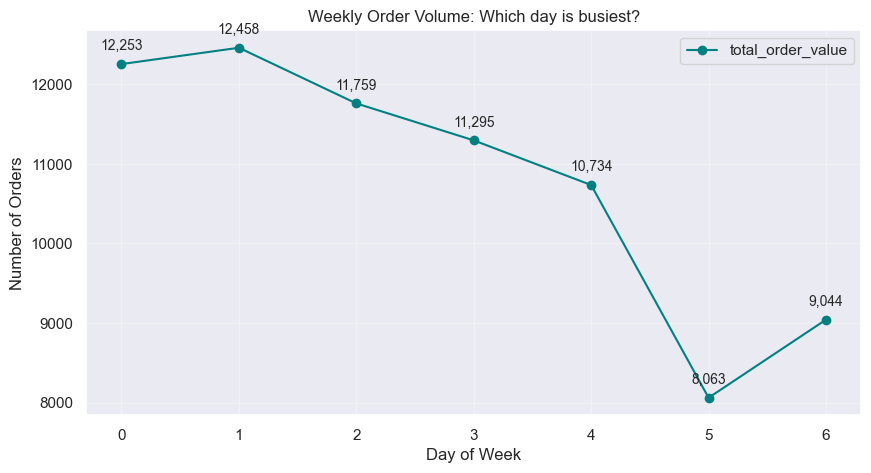

In [1287]:
top_revenue_states = ['SP', 'RJ', 'MG'] #Top revenue generating Customer States

best_revenue_state = df_1[(df_1['order_status']== 'delivered')&(df_1['customer_state'].isin(top_revenue_states))] #filtering my dateframe rows for the top three states

weekly_aggregation = (best_revenue_state[best_revenue_state['order_status']== 'delivered']
                      .groupby(['day_of_week'])['total_order_value']
                      .count() #get a count of 
                     .reindex(['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()
                     )
ax = weekly_aggregation.plot(kind='line', marker='o', figsize=(10, 5), color='teal')
for i, row in weekly_aggregation.iterrows():
    ax.annotate(f"{row['total_order_value']:,}", 
                (i, row['total_order_value']), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontsize=10)

plt.title("Weekly Order Volume: Which day is busiest?")
plt.ylabel("Number of Orders")
plt.xlabel("Day of Week")
plt.grid(True, alpha=0.3)
plt.show()

**Insight:**

Throughout the week, Tuesday, is when customers order the most. Toward the end of the week people orders declines. 

### Unsuccessful Deliveries Per Day (Logistics)

On which days do unsuccessful deliveries occur most frequently?

#### Hypothesis

Unsuccessful deliveries increase during weekdays when customers are less likely to be home.

In [1237]:
delivered_not = df_1[df_1['order_status'] != 'delivered']#&(df_1['customer_state'].isin(top_revenue_states))] #filtering my dateframe rows for the top three states
no_delivery = delivered_not.copy()
no_delivery['shipping_limit_date_week_day'] = pd.to_datetime(no_delivery['shipping_limit_date']).dt.day_name() #seller gets order to Logistics firm after approved.

weekly_aggregation = (no_delivery.groupby(['day_of_week'])['order_status']
                      .count() #get a count of 
                     .reindex(['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday'])
                      .reset_index()
                     )
weekly_aggregation  = weekly_aggregation.rename(columns={'day_of_week':'Week Day', 'order_status':'Volume'})

print(f"Not Delivered\n\n {weekly_aggregation.to_string(index=False)}")

Not Delivered

  Week Day  Volume
   Monday     402
  Tuesday     362
Wednesday     358
 Thursday     392
   Friday     343
 Saturday     271
   Sunday     271


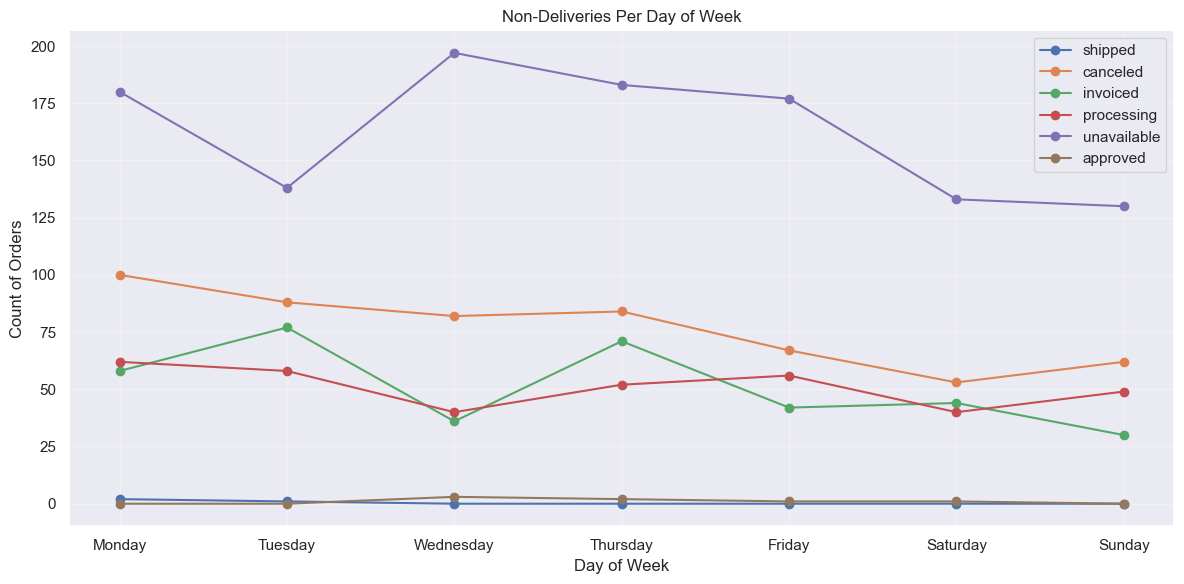

In [1003]:
# 1. Create one single aggregation (Pivot Table)
pivot_no_delivery = (no_delivery
                     .groupby(['day_of_week', 'order_status'])
                     .size()
                     .unstack(fill_value=0) # This turns statuses into columns
                     .reindex(['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday'])
                    )

# 2. Plot it all at once
plt.figure(figsize=(12, 6))
pivot_no_delivery.plot(marker='o', ax=plt.gca()) # ax=plt.gca() keeps it in the same figure

# 3. Clean up the labels
plt.title("Non-Deliveries Per Day of Week")
plt.ylabel("Count of Orders")
plt.xlabel("Day of Week")
plt.grid(True, alpha=0.3)
# plt.legend(title="Order Status", bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside
plt.legend(['shipped','canceled','invoiced','processing', 'unavailable', 'approved'])
plt.tight_layout()
plt.show()

**Insight:**

Order shipped has the highest amount of unsuccessful deliveries, consistently throughout the week.

**Section Transition:**

After examining individual variables in the Time-Series Analysis, the next step is to exploring deeper part concentrating one soley the impacts of the business to variables.


# Business Exploration

### Revenue Per Year (Sales)

Which year generated the most revenue?

#### Hypothesis

Revenue increases each year as more customers and sellers join the platform.

In [1362]:
years_performance = (df_1
                     .loc[df_1['order_status'] == 'delivered']
                     .groupby(['order_year'])['payment_value']
                     .sum().reset_index()
                     .sort_values(by='payment_value', ascending=False)
                    )
year = years_performance.copy()
year['payment_value'] = year['payment_value'].map('{:,.2f}'.format)
year = year.rename(columns={'order_year':'Year', 'payment_value':'Total Revenue (R$)'})

print(f"Revenue Per Year\n{year.to_string(index=False)}")

Revenue Per Year
 Year Total Revenue (R$)
 2018      10,690,016.00
 2017       8,673,033.03
 2016          60,768.10


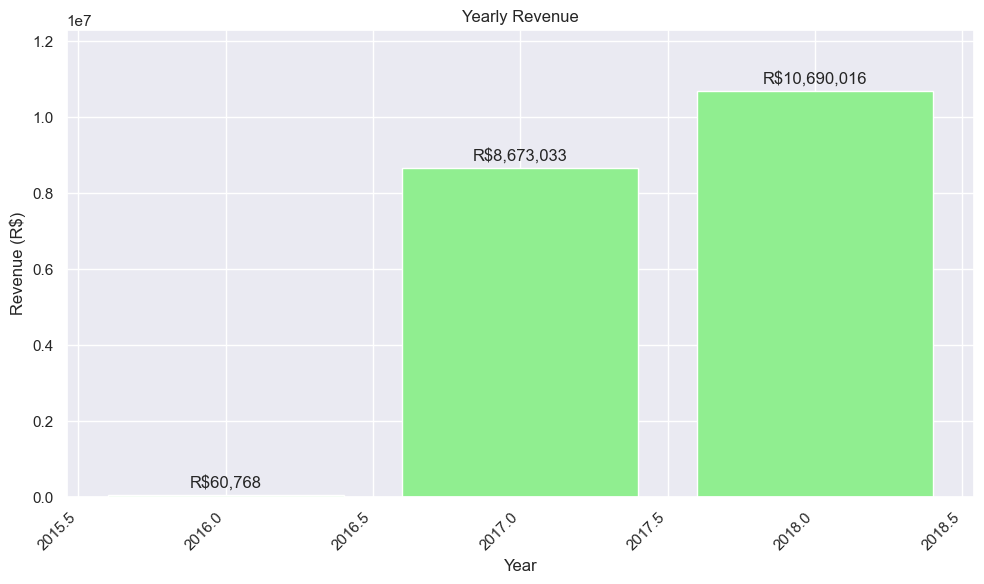

In [1019]:

plt.figure(figsize=(10, 6))

bars = plt.bar(years_performance['order_year'], years_performance['payment_value'], color='lightgreen') 

plt.bar_label(bars, padding=3, fmt='R${:,.0f}')

plt.title('Yearly Revenue') 
plt.xlabel('Year')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')

plt.ylim(0, years_performance['payment_value'].max() * 1.15) #Expand the bar chart y-axis slightly so labels don't hit the edge

plt.tight_layout()
plt.show()

**Insight:**

2018 earned the most revenue, indicating Olist business growth.

### Revenue by Product Category (Product)

 What product category generates the most revenue?

#### Hypothesis

Home and lifestyle products generate the highest revenue.

In [1361]:
rev_per_cat = (
    df_1.groupby('product_category_name_english')['payment_value'].agg(['mean', 'sum']).sort_values(by='sum', ascending=False)
    .reset_index()
              )
rev_and_mean = rev_per_cat.copy()

rev_and_mean['mean'] = rev_and_mean['mean'].map('{:,.2f}'.format)
rev_and_mean['sum'] = rev_and_mean['sum'].map('{:,.2f}'.format)
rev_and_mean = rev_and_mean.rename(columns={'mean': 'Average Price', 'sum': 'Total Revenue (R$)', 'product_category_name_english': 'Product Category'})
print(f"Revenue by Product (Top 10)\n\n{rev_and_mean.head(10).to_string(index=False)}")

Revenue by Product (Top 10)

     Product Category Average Price Total Revenue (R$)
       bed_bath_table        145.65       1,725,465.67
        health_beauty        165.56       1,646,292.53
computers_accessories        196.50       1,592,611.66
      furniture_decor        163.24       1,427,214.01
        watches_gifts        230.59       1,420,682.17
       sports_leisure        155.51       1,390,581.87
           housewares        148.92       1,091,709.15
         garden_tools        183.14         834,757.45
                 auto        184.17         802,254.74
           cool_stuff        194.91         772,616.70


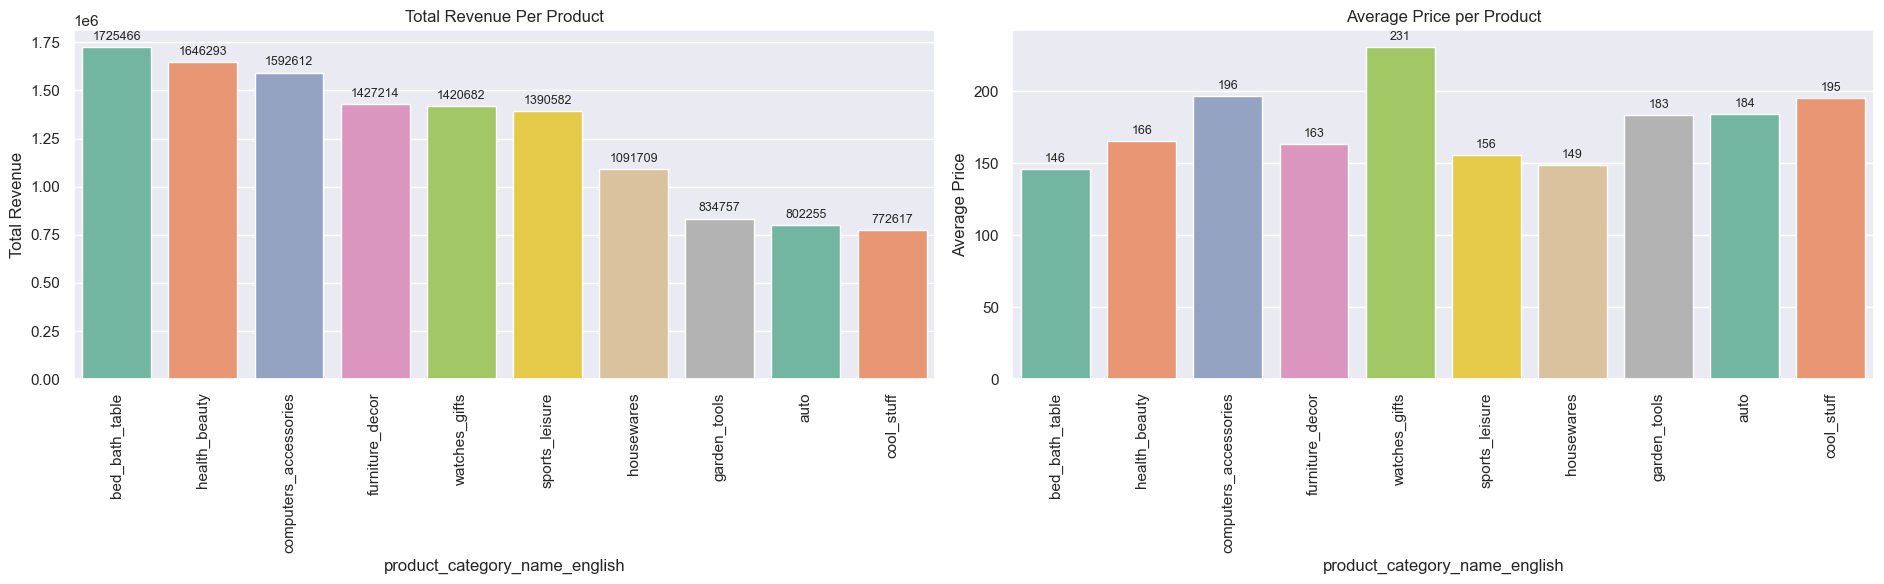

In [1309]:
rev_per_cats = rev_per_cats.rename(columns={'mean': 'Average Price', 'sum': 'Total Revenue'})

order = (rev_per_cats.sort_values('Total Revenue', ascending=False)
         ['product_category_name_english']
         .unique())
fig, ax = plt.subplots(1, 2, figsize=(19, 6))
# We set hue='product_category_name_english' to satisfy the new requirement
sns.barplot(x='product_category_name_english', y='Total Revenue', data=rev_per_cats, 
            hue='product_category_name_english', palette="Set2", ax=ax[0], legend=False)
ax[0].set_title("Total Revenue Per Product")
ax[0].tick_params(axis='x', rotation=90) # 90 degrees usually fits category names better

# 3. Average Price Plot
sns.barplot(x='product_category_name_english', y='Average Price', data=rev_per_cats, 
            hue='product_category_name_english', palette="Set2", ax=ax[1], legend=False)
ax[1].set_title("Average Price per Product")
ax[1].tick_params(axis='x', rotation=90)

for i in range(2):
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

**Insight:**

Bed Bath Table earn majority revenue with an average price point of R$146.

### Shipped Products Not Delivered (Logistics)

Do longer delivery times increase the likelihood of unsuccessful deliveries?

#### Hypothesis

Orders with longer delivery times are more likely to be undelivered.

In [1077]:

undelivered_orders = df_1[df_1['order_status'] != 'delivered']#&(df_1['customer_state'].isin(top_revenue_states))] #filtering my dateframe rows for the top three states

orders_not_deliver = undelivered_orders.copy()

orders_not_deliver['delivery_time'] = pd.to_datetime(orders_not_deliver['order_estimated_delivery_date']) - pd.to_datetime(orders_not_deliver['shipping_limit_date'])
orders_not_deliver['delivery_time'] = orders_not_deliver['delivery_time'].dt.days
orders_not_delivered = orders_not_deliver.copy()

orders_not = orders_not_delivered.groupby('order_status')['delivery_time'].agg(['mean', 'count']).sort_values(by='mean', ascending=False).reset_index()

orders_not = orders_not.rename(columns={'mean':'Shipping Days Avg', 'count':'Number of Orders', 'order_status': 'Order Status'})
orders_not['Shipping Days Avg'] = orders_not['Shipping Days Avg'].map('{:,.0f}'.format).astype(int)

print(f"Undelivered Items Status & Average Deliver\n\n{orders_not.to_string(index=False)}")

Undelivered Items Status & Average Deliver

Order Status  Shipping Days Avg  Number of Orders
 unavailable                 47                 7
  processing                 18               357
     shipped                 17              1138
    invoiced                 17               358
    approved                 16                 3
    canceled                 12               536


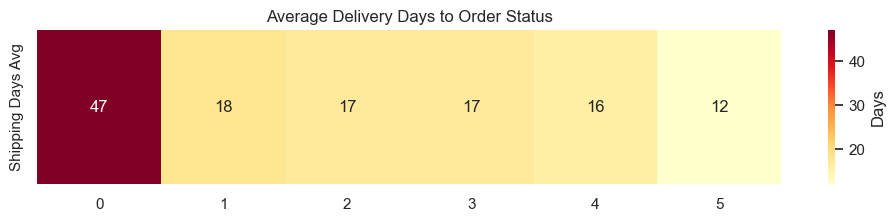

In [1085]:
heatmap_data = orders_not[['Shipping Days Avg']].T

plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', cbar_kws={'label': 'Days'})
plt.title('Average Delivery Days to Order Status')
plt.show()

**Insight:**

Higher delivery days shows Unavailable orders leading at 47 days, indicating the product got lost during deliery.

### Average Shipping time by Seller (Seller) 

Do sellers with faster shipping times generate more revenue?

#### Hypothesis

Sellers with faster shipping times generate higher revenue.

In [1359]:

delivered = df_1[df_1['order_status'] == 'delivered']

sellers_delivered = delivered.copy()
sellers_revenue = delivered.copy()

sellers_delivered['delivery_time'] = (pd.to_datetime(sellers_delivered['shipping_limit_date']) - pd.to_datetime(sellers_delivered['order_approved_at'])
                                     )
sellers_delivered['delivery_time'] = sellers_delivered['delivery_time'].dt.days


seller_orders = (
    sellers_delivered
    .groupby('seller_id')['delivery_time']
    .agg(['mean', 'count'])
    .reset_index()
)


revenue_per_seller = (sellers_revenue
 .groupby('seller_id')['payment_value']
 .sum().reset_index()
                     )
seller_order_revenue = seller_orders.merge(revenue_per_seller, on='seller_id').sort_values(by='payment_value', ascending=False)

seller_order_revenue = seller_order_revenue.rename(columns={'seller_id':'Seller ID','mean':'Shipping Days (Avg)', 'count':'Number of Orders', 'payment_value': 'Total Revenue'})

seller_order_revenues = seller_order_revenue.copy()
seller_order_revenues['Shipping Days (Avg)'] = seller_order_revenues['Shipping Days (Avg)'].map('{:,.0f} days'.format)
seller_order_revenues['Total Revenue (R$)'] = seller_order_revenues['Total Revenue'].map('{:,.0f}'.format)

seller_order_revenues = seller_order_revenues.drop('Total Revenue', axis=1)

print(f"Seller Average Shipping time to Revenue (Top 10)")
print(f"{seller_order_revenues.head(10).to_string(index=False)}")

Seller Average Shipping time to Revenue (Top 10)
                       Seller ID Shipping Days (Avg)  Number of Orders Total Revenue (R$)
7c67e1448b00f6e969d365cea6b010ab             13 days              1445            507,744
1025f0e2d44d7041d6cf58b6550e0bfa              6 days              1456            308,309
4a3ca9315b744ce9f8e9374361493884              5 days              2093            297,597
1f50f920176fa81dab994f9023523100              5 days              2003            290,337
53243585a1d6dc2643021fd1853d8905              6 days               425            277,690
da8622b14eb17ae2831f4ac5b9dab84a              6 days              1650            275,182
4869f7a5dfa277a7dca6462dcf3b52b2              5 days              1170            259,994
955fee9216a65b617aa5c0531780ce60              5 days              1492            230,667
fa1c13f2614d7b5c4749cbc52fecda94              5 days               598            201,922
6560211a19b47992c3666cc44a7e94c0              5 day

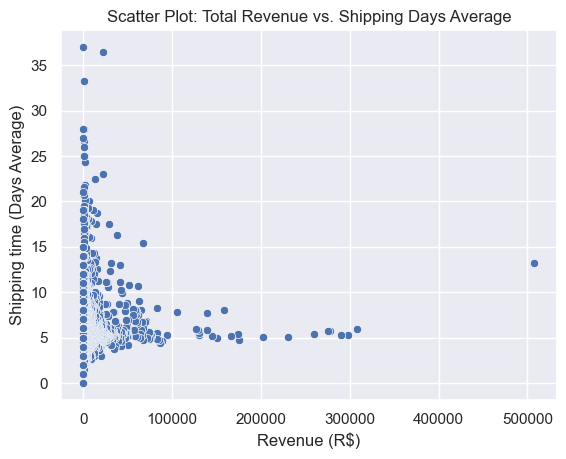

In [1129]:
scatter_seller = seller_order_revenue.copy()
sns.scatterplot(x='Total Revenue', y='Shipping Days Avg', data=scatter_seller) 
plt.title('Scatter Plot: Total Revenue vs. Shipping Days Average') 
plt.xlabel('Revenue (R$)')
plt.ylabel('Shipping time (Days Average)')
plt.show()

**Insight:**

Large group of deliveries under R$100k primarily take 5-10 days, suggesing speed of delivery does not generate more revenue. 


### Top 10 Earning Sellers by State (Marketplace)

Which states have the highest-earning sellers?

#### Hypothesis

Sellers with faster shipping times generate higher revenue.

In [1384]:
state_seller = (df_1.loc[df_1['order_status'] == 'delivered']
                .groupby(['seller_state_name'])['payment_value']
                .sum()
                .reset_index()
                .sort_values(by='payment_value', ascending=False))

total_revenue = state_seller['payment_value'].sum()
state_seller['Contribution (%)'] = (state_seller['payment_value'] / total_revenue) * 100

state_seller = state_seller.rename(columns={'seller_state_name':'State', 'payment_value':'Total Revenue (R$)'})

report_table = state_seller.copy()

report_table['Total Revenue (R$)'] = report_table['Total Revenue (R$)'].map('{:,.2f}'.format)
report_table['Contribution (%)'] = report_table['Contribution (%)'].map('{:.2f}%'.format)

print(f"Sellers State by Total Revenue\n\n{report_table.head(10).to_string(index=False)}")

Sellers State by Total Revenue

            State Total Revenue (R$) Contribution (%)
        São Paulo      12,773,654.85           65.76%
           Paraná       1,779,763.03            9.16%
     Minas Gerais       1,477,704.54            7.61%
   Rio de Janeiro       1,049,028.24            5.40%
   Santa Catarina         847,124.17            4.36%
Rio Grande do Sul         545,013.23            2.81%
            Bahia         357,909.62            1.84%
 Distrito Federal         132,436.25            0.68%
       Pernambuco         122,418.52            0.63%
            Goiás         108,716.76            0.56%


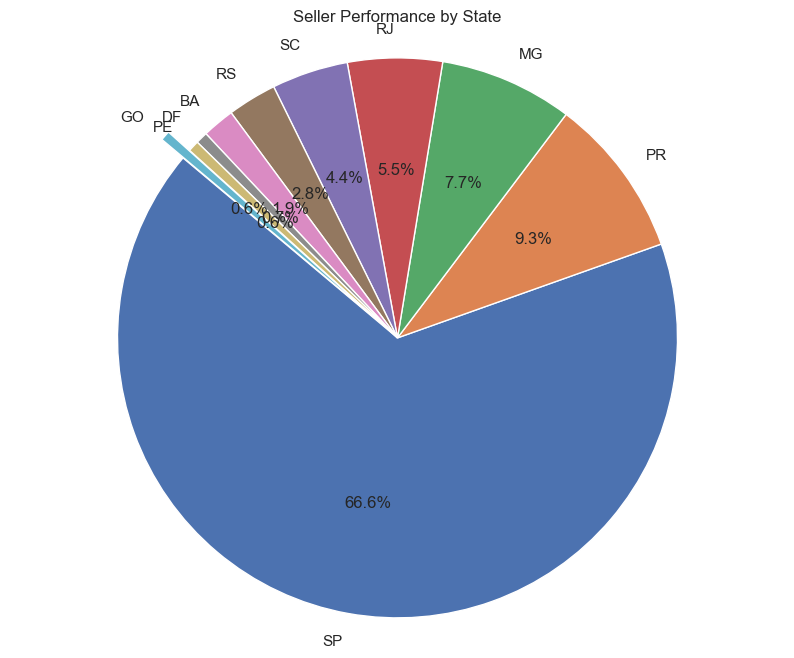

In [1332]:
# Prepare the data (Ensure we have the right number of slices)
seller_performances = seller_performance.head(10)
data = seller_performances['payment_value']
labels = seller_performances['seller_state']

# Dynamic Explode: Ensure the explode array matches the data length
# This creates 0s for everything except the very last item
explode = np.zeros(len(data))
explode[-1] = 0.1 

# 3. Plotting
plt.figure(figsize=(10, 8))
plt.pie(data, 
        explode=explode, 
        labels=labels, 
        autopct='%1.1f%%', # Standard format for 1 decimal point
        shadow=False, 
        startangle=140)

plt.axis('equal') 
plt.title('Seller Performance by State')
plt.show()

**Insight:**

Sellers from São Paulo(SP) generates the most revenue. 

### Popular Item purchased by State (Product)

What product categories are most popular in each state?

#### Hypothesis

Sellers with faster shipping times generate higher revenue.

In [1385]:
# 1. Get the counts for every State + Category combination
state_counts = (df_1[df_1['order_status'] == 'delivered']
                .groupby(['customer_state_name', 'product_category_name_english'])
                .size()
                .reset_index(name='count'))

# 2. For each state, find the row with the maximum count
# We sort by count, then take the last row for each state
popular_items = (state_counts.sort_values(['customer_state_name', 'count'])
                 .groupby('customer_state_name')
                 .tail(1)
                 .sort_values('count', ascending=False)
                 .reset_index(drop=True))
popular_item = popular_items.copy()
popular_item = popular_item.rename(columns={'customer_state_name':'State', 'product_category_name_english':'Product Category', 'count':'Volume'})

print(f"Top Product Purchased per State\n\n{popular_item.to_string(index=False)}")

Top Product Purchased per State

              State Product Category  Volume
          São Paulo   bed_bath_table    5527
     Rio de Janeiro   bed_bath_table    1720
       Minas Gerais   bed_bath_table    1396
  Rio Grande do Sul   bed_bath_table     668
             Paraná  furniture_decor     537
              Bahia    health_beauty     383
     Santa Catarina   sports_leisure     366
              Goiás   bed_bath_table     249
   Distrito Federal    health_beauty     247
     Espírito Santo   bed_bath_table     239
         Pernambuco    health_beauty     230
              Ceará    health_beauty     169
               Pará    health_beauty     106
        Mato Grosso    health_beauty      91
           Maranhão    health_beauty      89
            Paraíba    health_beauty      82
 Mato Grosso do Sul   sports_leisure      81
Rio Grande do Norte    health_beauty      67
            Alagoas    health_beauty      67
              Piauí    health_beauty      55
            Sergipe   

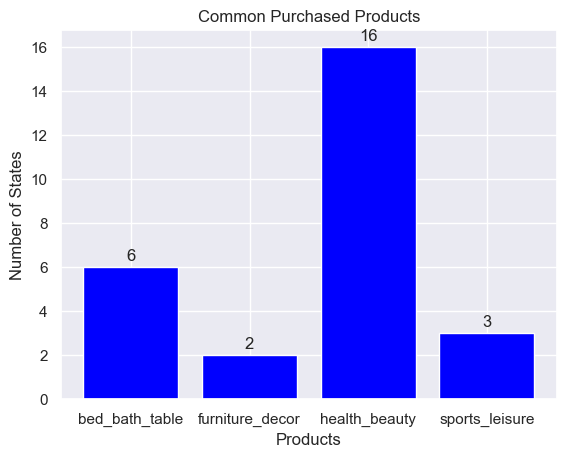

In [1319]:
plot_products = (popular_items.groupby('product_category_name_english')['customer_state'].size().reset_index()
                )

bars = plt.bar(plot_products['product_category_name_english'],plot_products['customer_state'], color='blue') 
plt.bar_label(bars, padding=3, fmt='{:,.0f}')
plt.title('Common Purchased Products') 
plt.xlabel('Products')
plt.ylabel('Number of States')
plt.show()

**Insight:**

Health Beauty products are commonly purchase, which shows Customers prefer to purchase their health as beauty products on Olist platform.

# Final Summary

### Dataset Overview


This analysis examined the Olist Brazilian E-commerce dataset, containing over 100,000 transactions from sellers and customers across Brazil. The objective of the analysis was to understand customer behaviour, logistic efficiency, seller performance, and revenue trends within the Olist marketplace.

### Key Findings


* The **Bed Bath Table** category generated the largest share of revenue, contributing to **8.79%** of total sales.
* Freight costs show little correlation with package weight,  suggesting shipping prices are influenced by additional factors such as distance or logistics provider pricing. 
* Customers are heavily concentrated in a few key states, particularly **São Paulo, which represents the largest customer base**.
* The state of **Paraíba (PB)** purchases a higher average price per item, in comparison to other key states.
* Credit cards are the most commonly used payment method, indicating strong customer preference for this payment type.
* Sellers located in **São Paulo (SP)** generate approximately **66% of Olist’s total marketplace revenue**. 
* Customers across most states frequently purchase **Health & Beauty Products**, making it one of the most consistently popular product categories nationwide.


### Business Insights


* Revenue concentration in specific regions suggests untapped growth opportunities in other regions such as **Rio de Janeiro (RJ), Minas Gerais (MG), Rio Grande do Sul (RS), and Paraná (PR)**. These states contain a large number of customers, but  contribute a smaller share of total revenue per State percentage: **RJ (5.5%), MG (7.7%), RS (2.8%), PR (9.3%)**. 
* Sellers take an average of **5-6 days to deliver products to Olist Logistic partners**, which may extend overall delivery time and impact customer experience. Marketplace performance improved significantly between **2017 and 2018**, with revenue increasing by approximately **R$2 million (+23.25%)**, suggesting strong platform growth. 

### Recommendations


* Implement targeted **seasonal marketing campaigns** during lower-performing months to stabilize revenue fluctuations. 
* Explore **strategic warehouse placement or logistics hubs** closer to high-volume regions such as  Sāo Paulo(SP) to reduce delivery times.
* Expand the availability of **higher-value product categories** to increase average order value and marketplace profitability..
* Evaluate opportunities to optimize freight costs, as the majority of shipping prices aggregate around **R$20**, indicating potential efficiency improvements in logistics operations.